<a href="https://colab.research.google.com/github/kondreddygarivani-bit/PROJECT-1-week1/blob/main/W_1_NETF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles_2021.csv to netflix_titles_2021.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
df = pd.read_csv('netflix_titles_2021.csv')

In [ ]:
#DATA EXPLORATION
print("\nFIRST FIVE ROWS OF THE DATASET")
print(df.head())


FIRST FIVE ROWS OF THE DATASET
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons 

In [ ]:
print("\nCOLUMNS IN THE DATASET")
print(df.columns)


COLUMNS IN THE DATASET
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [ ]:
print("DATASETSHAPE")
print(df.shape)
print("\nDATASET INFORMATION")
print(df.info)

DATASETSHAPE
(8807, 12)

DATASET INFORMATION
<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United Stat

In [ ]:
print("STASTICAL SUMMARY")
print(df.describe)
print("\nMISSING VALUES")
print(df.isnull().sum())

STASTICAL SUMMARY
<bound method NDFrame.describe of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, K


MISSING VALUES
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

DUPLICATES : 0

MOVIES VS TV SHOWS
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


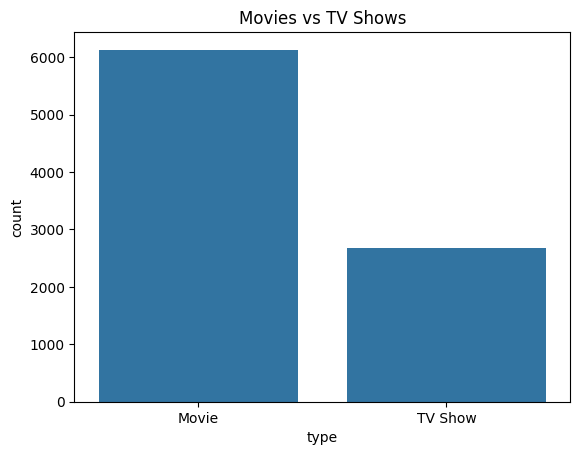

In [ ]:
import pandas as pd
df = pd.read_csv('netflix_titles_2021.csv')

# STEP 4 - CHECK MISSING VALUES

print("\nMISSING VALUES")
print(df.isnull().sum())

# STEP 5 - REMOVE DUPLICATES

print("\nDUPLICATES :", df.duplicated().sum())

df = df.drop_duplicates()

# STEP 6 - HANDLE MISSING VALUES

df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# STEP 7 - CONTENT TYPE ANALYSIS

print("\nMOVIES VS TV SHOWS")
print(df['type'].value_counts())

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()


TOP COUNTRIES
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


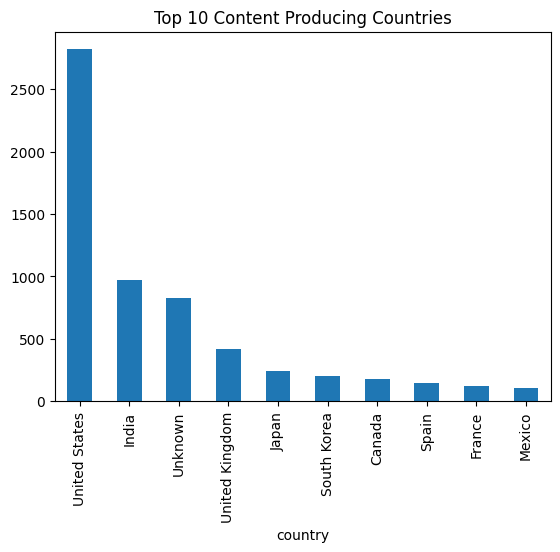


CONTENT RATINGS
rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


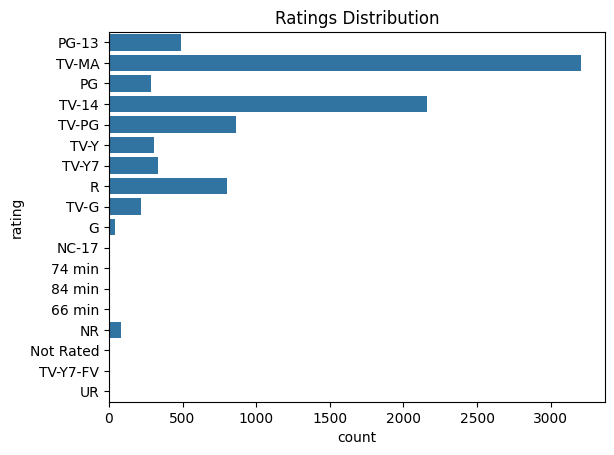

In [ ]:
# STEP 8 - MOST COMMON COUNTRIES

top_countries = df['country'].value_counts().head(10)

print("\nTOP COUNTRIES")
print(top_countries)

top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

# STEP 9 - MOST COMMON RATINGS

print("\nCONTENT RATINGS")
print(df['rating'].value_counts())

sns.countplot(y='rating', data=df)
plt.title("Ratings Distribution")
plt.show()


FIRST 5 ROWS
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

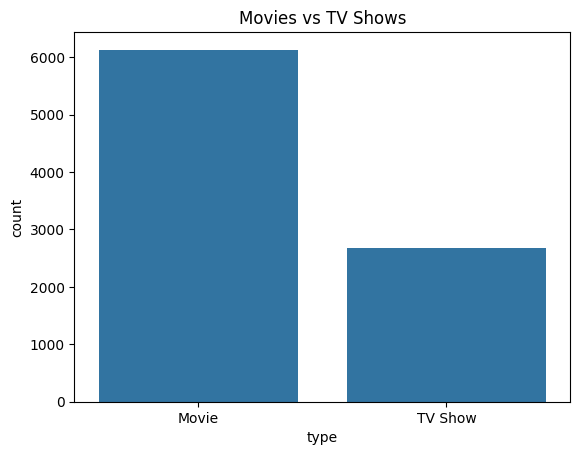


TOP COUNTRIES
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


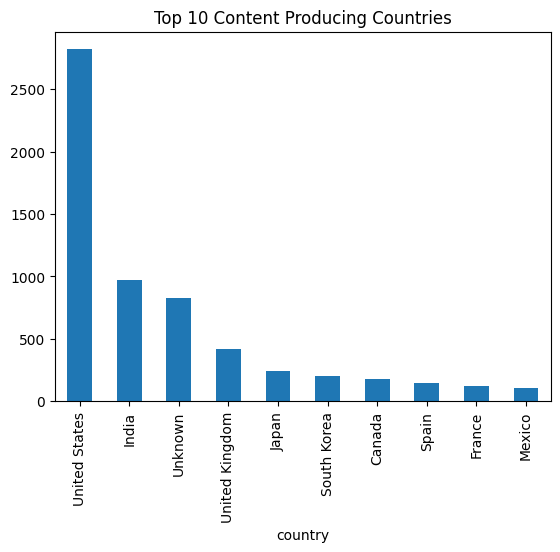


CONTENT RATINGS
rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


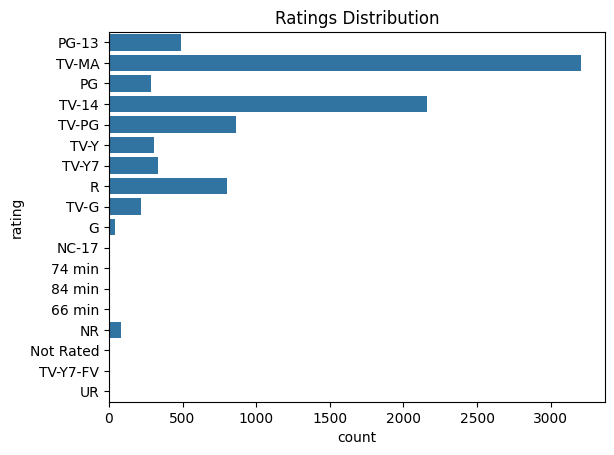

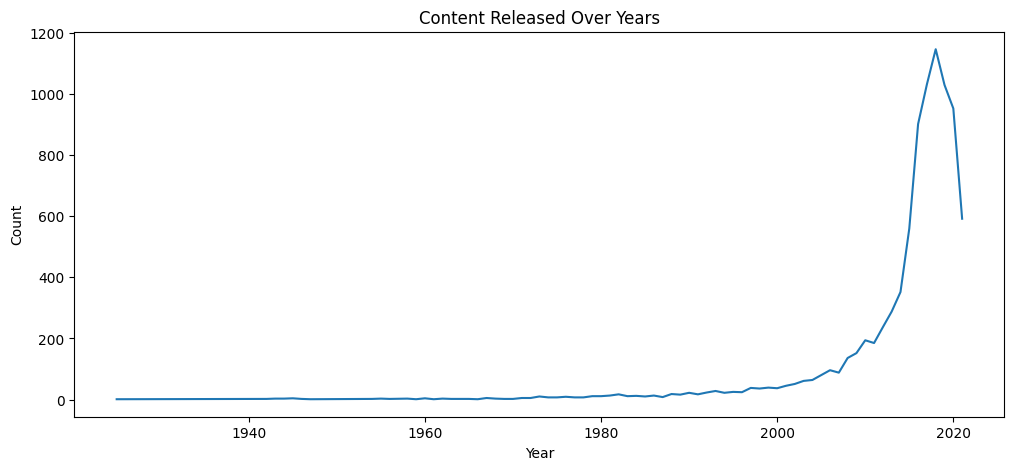


TOP GENRES
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


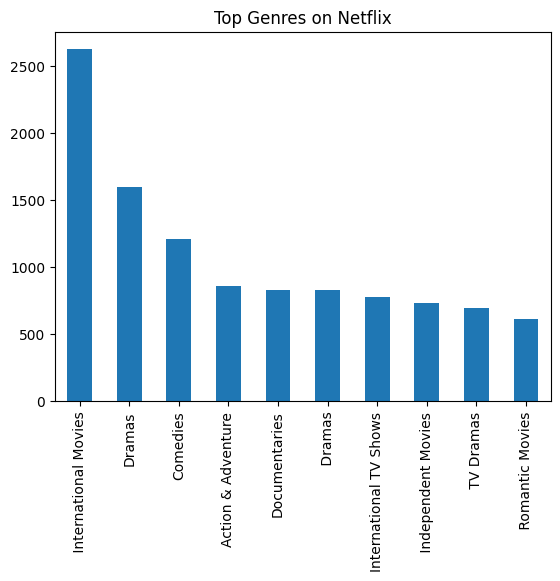

In [ ]:
# ==========================================
# NETFLIX DATA ANALYSIS PROJECT
# ==========================================

# STEP 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2 - LOAD DATASET

df = pd.read_csv('netflix_titles_2021.csv')

# STEP 3 - BASIC INFORMATION

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

# STEP 4 - CHECK MISSING VALUES

print("\nMISSING VALUES")
print(df.isnull().sum())

# STEP 5 - REMOVE DUPLICATES

print("\nDUPLICATES :", df.duplicated().sum())

df = df.drop_duplicates()

# STEP 6 - HANDLE MISSING VALUES

df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# STEP 7 - CONTENT TYPE ANALYSIS

print("\nMOVIES VS TV SHOWS")
print(df['type'].value_counts())

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

# STEP 8 - MOST COMMON COUNTRIES

top_countries = df['country'].value_counts().head(10)

print("\nTOP COUNTRIES")
print(top_countries)

top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

# STEP 9 - MOST COMMON RATINGS

print("\nCONTENT RATINGS")
print(df['rating'].value_counts())

sns.countplot(y='rating', data=df)
plt.title("Ratings Distribution")
plt.show()

# STEP 10 - RELEASE YEAR ANALYSIS

year_data = df['release_year'].value_counts().sort_index()

year_data.plot(figsize=(12,5))
plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# STEP 11 - MOST COMMON GENRES

genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

print("\nTOP GENRES")
print(top_genres)

top_genres.plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

In [ ]:
# STEP 12 - SIMPLE MACHINE LEARNING MODEL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# SELECT FEATURES

ml_df = df[['type', 'rating', 'release_year']].copy()

# REMOVE MISSING VALUES

ml_df = ml_df.dropna()

# ENCODING

encoder = LabelEncoder()

ml_df['type'] = encoder.fit_transform(ml_df['type'])
ml_df['rating'] = encoder.fit_transform(ml_df['rating'])

# FEATURES AND TARGET

X = ml_df[['release_year', 'rating']]
y = ml_df['type']

# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# TRAIN MODEL

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

# PREDICTION

y_pred = model.predict(X_test)

# ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY :", accuracy)


MODEL ACCURACY : 0.7150964812712827
